CS 422 Overwatch Simple Model

In [329]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Display stuff for easy edits

In [330]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Set up teams

In [331]:
df = pd.read_csv("Reduced_Stats.csv")

In [332]:
print(f"Original dataset shape: {df.shape}")
print(f"Expected number of games: {df.shape[0] // 10}")

Original dataset shape: (6110, 14)
Expected number of games: 611


In [333]:
features = [
    "Eliminations", "Damage Dealt", "Assists", "Objective Time",
    "Damage Mitigated", "Healing Done", "Deaths",
    "Solo Kills", "Final Blows"
]

In [334]:
team_data_frame = df.groupby(
    ["match_id", "round_num", "team"]
)[features + ["Result"]].first().reset_index()

In [335]:
grouped = team_data_frame.groupby(["match_id", "round_num"])

In [336]:
X_rows = []
y_rows = []

for (match, round_), group in grouped:

    if len(group) != 2:
        continue

    t1 = group.iloc[0]
    t2 = group.iloc[1]

    diff = t1[features] - t2[features]

    X_rows.append(diff.values)
    y_rows.append(int(t1["Result"]))

In [337]:
X = pd.DataFrame(X_rows, columns=features)
y = pd.Series(y_rows)

Train/Split here

In [338]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale

In [339]:
scaler = StandardScaler()

In [340]:
X_train = scaler.fit_transform(X_train)

In [341]:
X_test = scaler.transform(X_test)

Train

In [342]:
model = LogisticRegression(max_iter=5000)

In [343]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predict

In [344]:
y_pred = model.predict(X_test)

Evaluation

MODEL PERFORMANCE (Logistic Regression)
Accuracy: 90.16%
F1 Score : 89.29%


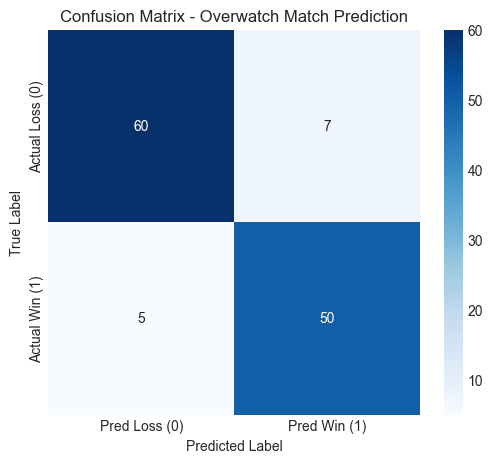

In [352]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# -------------------------
# Print metrics (clean format)
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Logistic Regression)")
print("="*50)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print("="*50)

# -------------------------
# Confusion Matrix (Heatmap)
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Overwatch Match Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Coefficients

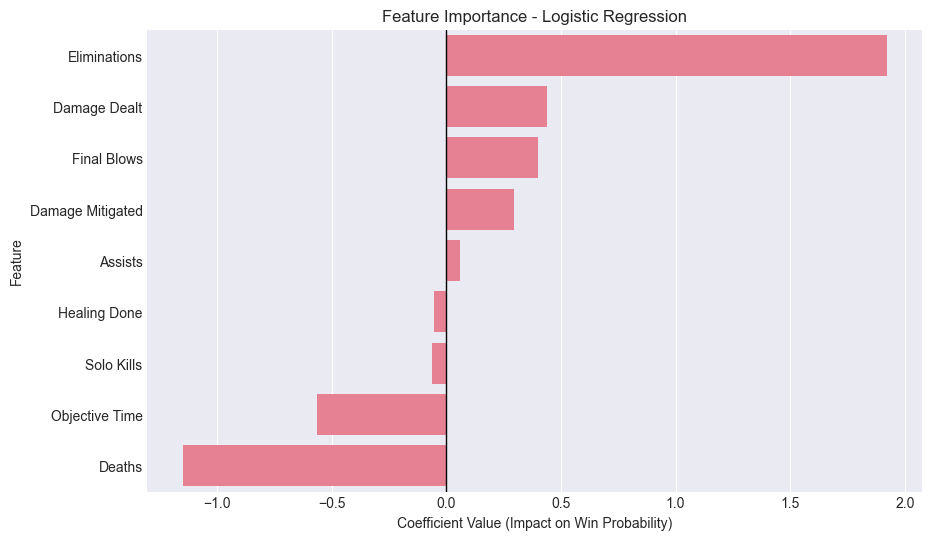

         Feature  Coefficient
    Eliminations     1.922541
    Damage Dealt     0.439418
     Final Blows     0.398106
Damage Mitigated     0.295091
         Assists     0.059821
    Healing Done    -0.052858
      Solo Kills    -0.060694
  Objective Time    -0.564025
          Deaths    -1.149213


In [356]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coeffs
)

plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value (Impact on Win Probability)")
plt.ylabel("Feature")

plt.axvline(0, color="black", linewidth=1)
plt.show()
print(coeffs.to_string(index=False))

In [355]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring="f1")
print("CV F1:", scores.mean())

CV F1: 0.8909118232647645
